# GeneAttention v6 — Deep CORAL + Label Smoothing

**Goal**: Maximise Target Domain Macro-F1 (GSE126030, unlabelled 10x data)  
**Source**: GSE108989 — Smart-seq2, 6 824 labelled T-cell subtypes  
**Target**: GSE126030 — 10x Genomics, 63 877 unlabelled cells  

## Architecture

```
Input (n_genes)
   │
   ├─ Attention Branch ─────────────────────────────────────────────────
   │     Dense(256, relu) → Dropout(0.1) → Dense(128, relu) → Dropout(0.1)
   │     → Dense(n_genes) → Softmax  =  gene_weights (n_genes,)
   │
   └─ Weighted Input: x * gene_weights
         │
      Dense(512, relu) → BatchNorm → Dropout(0.3)
      Dense(256, relu) → BatchNorm → Dropout(0.3)
      Dense(128, relu)                          ← latent z (128-d)
         │
      Dense(n_classes, softmax)                 ← predictions
```

## Losses (v6 additions over v5 in **bold**)

| Component | Weight | Note |
|---|---|---|
| CE (label-smooth **ε=0.1**) + Mixup | 1.0 | Source supervised |
| MMD (RBF multi-scale) | 0 → 0.30 | Input-space alignment |
| Centroid alignment | 0 → 0.30 | Soft class-conditional |
| **Deep CORAL** | **0 → 0.20** | **Latent covariance alignment** |
| Entropy minimisation | 0 → 0.15 | Confident target predictions |

All adaptation losses ramped linearly 0 → max over first 15 epochs.

## What's new in v6 vs v5
- **Deep CORAL** — `CORAL(z_src, z_tgt)` in 128-d latent space: Frobenius norm of covariance difference
- **Label smoothing ε=0.1** — soft one-hot targets prevent overconfident source fitting

## 0 · Imports & seeds

In [60]:
import os, json, warnings, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.21.0 | GPU: []


## 1 · Data loading

In [61]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# ── Source (GSE108989) ──────────────────────────────────────────────────────
X_train = np.load(os.path.join(ROOT, "step3_X_train.npy")).astype(np.float32)
X_test  = np.load(os.path.join(ROOT, "step3_X_test.npy" )).astype(np.float32)
y_train = np.load(os.path.join(ROOT, "step3_y_train.npy")).astype(np.int64)
y_test  = np.load(os.path.join(ROOT, "step3_y_test.npy" )).astype(np.int64)

with open(os.path.join(ROOT, "step3_label_mapping.json")) as f:
    label_map  = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

y_train_enc = y_train
y_test_enc  = y_test

# ── Target raw (GSE126030) — v2 preprocessing ──────────────────────────────
tgt_candidates = [
    os.path.join(ROOT, "gse126030_preprocessed_v2.npy"),
    os.path.join(ROOT, "gse126030_preprocessed.npy"),
]
X_tgt_raw = None
for p in tgt_candidates:
    if os.path.exists(p):
        X_tgt_raw = np.load(p).astype(np.float32)
        print(f"Target loaded from: {os.path.basename(p)}")
        break
if X_tgt_raw is None:
    raise FileNotFoundError(
        "No target file found. Run step3_v2.py then preprocess_target_v2.py first."
    )

# ── CORAL alignment (input-space covariance) ────────────────────────────────
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0]-1) + reg*np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0]-1) + reg*np.eye(Xt.shape[1])
    def msqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T
    def minvsqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(1.0/np.sqrt(np.maximum(v, 1e-10))) @ V.T
    return ((Xt @ (minvsqrt(Ct) @ msqrt(Cs))) + src_mean).astype(np.float32)

print("Running CORAL alignment...")
X_tgt = coral_align(X_train, X_tgt_raw)
print(f"Post-CORAL mean diff (abs): {np.abs(X_train.mean(0) - X_tgt.mean(0)).mean():.4f}")

# ── Pseudo-labels for target eval ────────────────────────────────────────────
label_csv = os.path.join(
    ROOT, "improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv"
)
df_labels = pd.read_csv(label_csv)
eval_mask = (df_labels["confidence"] >= 0.55) & (df_labels["new_class"] != "Uncertain")
y_target_eval = np.array(
    [class_names.index(n) for n in df_labels.loc[eval_mask, "new_class"]], dtype=np.int64
)
X_target_eval = X_tgt[eval_mask.values]

print(f"\nSource train : {X_train.shape}  test : {X_test.shape}")
print(f"Target total : {X_tgt.shape}  eval subset: {X_target_eval.shape}")
print(f"Classes ({n_classes}): {class_names}")
print(f"Genes        : {n_genes}")

Target loaded from: gse126030_preprocessed_v2.npy
Running CORAL alignment...
Post-CORAL mean diff (abs): 0.0000

Source train : (6824, 2701)  test : (1706, 2701)
Target total : (63877, 2701)  eval subset: (12776, 2701)
Classes (6): ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Genes        : 2701


## 2 · Class weights

In [62]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_train_enc)
class_weights = tf.constant(cw, dtype=tf.float32)

for i, (cls, w) in enumerate(zip(class_names, cw)):
    print(f"  {cls:20s}: {w:.4f}")

  Effector            : 0.5908
  Exhausted           : 1.7103
  Naive               : 1.2665
  Other_CD4           : 0.8858
  Th1-like            : 2.0165
  Treg                : 0.7643


## 3 · Ramp callback

In [63]:
class EpochRampCallback(keras.callbacks.Callback):
    """Linearly ramp tf.Variable weights from 0 to max_val over ramp_epochs."""
    def __init__(self, variables, max_vals, ramp_epochs=15):
        super().__init__()
        self.variables   = variables
        self.max_vals    = max_vals
        self.ramp_epochs = ramp_epochs

    def on_epoch_begin(self, epoch, logs=None):
        frac = min(1.0, epoch / self.ramp_epochs)
        for var, mx in zip(self.variables, self.max_vals):
            var.assign(frac * mx)

## 4 · Model definition — GeneAttentionV6

In [64]:
class GeneAttentionV6(keras.Model):
    """
    GeneAttention v6: Deep CORAL (latent covariance) + label-smoothing CE.
    Extends v5 architecture (2-layer attention, MMD, centroid, entropy).
    """

    def __init__(self, n_genes, n_classes, latent_dim=128,
                 dropout_att=0.1, dropout_enc=0.3,
                 label_smooth_eps=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_genes    = n_genes
        self.n_classes  = n_classes
        self.latent_dim = latent_dim
        self.eps        = label_smooth_eps

        # ── Attention branch ────────────────────────────────────────────────
        self.att_h1  = layers.Dense(256, activation="relu")
        self.att_d1  = layers.Dropout(dropout_att)
        self.att_h2  = layers.Dense(128, activation="relu")
        self.att_d2  = layers.Dropout(dropout_att)
        self.att_out = layers.Dense(n_genes)   # logits

        # ── Encoder trunk ───────────────────────────────────────────────────
        self.enc1  = layers.Dense(512, activation="relu")
        self.bn1   = layers.BatchNormalization()
        self.drp1  = layers.Dropout(dropout_enc)
        self.enc2  = layers.Dense(256, activation="relu")
        self.bn2   = layers.BatchNormalization()
        self.drp2  = layers.Dropout(dropout_enc)
        self.enc3  = layers.Dense(latent_dim, activation="relu")   # z

        # ── Classifier head ─────────────────────────────────────────────────
        self.clf = layers.Dense(n_classes, activation="softmax")

        # ── Adaptive loss weights (ramped by callback) ───────────────────────
        self.w_mmd      = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.w_centroid = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.w_coral    = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.w_ent      = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        # ── Metric trackers ─────────────────────────────────────────────────
        self.loss_t   = keras.metrics.Mean(name="loss")
        self.ce_t     = keras.metrics.Mean(name="ce_loss")
        self.mmd_t    = keras.metrics.Mean(name="mmd_loss")
        self.cen_t    = keras.metrics.Mean(name="cen_loss")
        self.coral_t  = keras.metrics.Mean(name="coral_loss")
        self.ent_t    = keras.metrics.Mean(name="ent_loss")
        self.acc_t    = keras.metrics.SparseCategoricalAccuracy(name="acc")

    # ── Forward pass ─────────────────────────────────────────────────────────
    def encode(self, x, training=False):
        att_logits = self.att_out(self.att_d2(
                       self.att_h2(self.att_d1(
                         self.att_h1(x, training=training),
                       training=training)),
                     training=training))
        gene_w = tf.nn.softmax(att_logits, axis=-1)   # (B, n_genes)
        xw = x * gene_w
        z  = self.enc3(
               self.drp2(self.bn2(self.enc2(
                 self.drp1(self.bn1(self.enc1(xw, training=training),
                           training=training),
                 training=training), training=training), training=training),
               training=training))
        return z, gene_w

    def call(self, x, training=False):
        z, _ = self.encode(x, training=training)
        return self.clf(z)

    # ── Loss helpers ─────────────────────────────────────────────────────────
    def _smooth_one_hot(self, y_int):
        y1h = tf.one_hot(y_int, self.n_classes)
        return y1h * (1.0 - self.eps) + self.eps / tf.cast(self.n_classes, tf.float32)

    def _mixup_ce(self, x_src, y_src, cw, training):
        """Mixup with label-smoothed soft CE."""
        B = tf.shape(x_src)[0]
        alpha = 0.2
        g1 = tf.random.gamma([B], alpha=alpha)
        g2 = tf.random.gamma([B], alpha=alpha)
        lam = g1 / (g1 + g2 + 1e-8)
        lam = tf.maximum(lam, 1.0 - lam)
        lam_x = tf.reshape(lam, [-1, 1])

        idx  = tf.random.shuffle(tf.range(B))
        x2   = tf.gather(x_src, idx)
        y2   = tf.gather(y_src, idx)

        x_mix = lam_x * x_src + (1.0 - lam_x) * x2

        y1h = self._smooth_one_hot(y_src)
        y2h = self._smooth_one_hot(y2)
        lam_y = tf.reshape(lam, [-1, 1])
        y_mix = lam_y * y1h + (1.0 - lam_y) * y2h

        z_mix, _ = self.encode(x_mix, training=training)
        logits_mix = self.clf(z_mix)
        log_p = tf.math.log(logits_mix + 1e-8)

        # Per-sample class weights from original labels
        w1 = tf.gather(cw, y_src)
        w2 = tf.gather(cw, y2)
        sample_w = lam * w1 + (1.0 - lam) * w2

        per_sample = -tf.reduce_sum(y_mix * log_p, axis=-1)
        return tf.reduce_mean(per_sample * sample_w)

    def _mmd_rbf(self, z_src, z_tgt):
        """Multi-scale RBF MMD with sort-based median bandwidth."""
        zall = tf.concat([z_src, z_tgt], axis=0)
        dists = tf.reduce_sum(tf.square(
            tf.expand_dims(zall, 0) - tf.expand_dims(zall, 1)), axis=-1)
        # TF-native median via sort
        flat  = tf.reshape(dists, [-1])
        flat  = tf.sort(flat)
        n_flat = tf.shape(flat)[0]
        sigma2 = tf.stop_gradient(
            tf.maximum(flat[n_flat // 2], 1e-3))

        def k(a, b):
            d = tf.reduce_sum(tf.square(
                tf.expand_dims(a, 1) - tf.expand_dims(b, 0)), axis=-1)
            return (tf.exp(-d / (2.0 * sigma2)) +
                    tf.exp(-d / (0.5 * sigma2)) +
                    tf.exp(-d / (8.0 * sigma2)))

        kss = tf.reduce_mean(k(z_src, z_src))
        ktt = tf.reduce_mean(k(z_tgt, z_tgt))
        kst = tf.reduce_mean(k(z_src, z_tgt))
        return kss + ktt - 2.0 * kst

    def _centroid_alignment(self, z_src, y_src, z_tgt, p_tgt):
        """Soft class-conditional centroid alignment."""
        loss = 0.0
        for c in range(self.n_classes):
            mask = tf.cast(tf.equal(y_src, c), tf.float32)
            n_c  = tf.reduce_sum(mask) + 1e-8
            mu_src = tf.reduce_sum(
                z_src * tf.reshape(mask, [-1, 1]), axis=0) / n_c

            w_tgt  = p_tgt[:, c:c+1]
            w_sum  = tf.reduce_sum(w_tgt) + 1e-8
            mu_tgt = tf.reduce_sum(z_tgt * w_tgt, axis=0) / w_sum

            loss += tf.reduce_mean(tf.square(mu_src - mu_tgt))
        return loss / tf.cast(self.n_classes, tf.float32)

    def _deep_coral(self, z_src, z_tgt):
        """Deep CORAL: Frobenius norm of latent covariance difference."""
        d  = tf.cast(tf.shape(z_src)[1], tf.float32)
        ns = tf.cast(tf.shape(z_src)[0], tf.float32)
        nt = tf.cast(tf.shape(z_tgt)[0], tf.float32)

        zs = z_src - tf.reduce_mean(z_src, axis=0, keepdims=True)
        zt = z_tgt - tf.reduce_mean(z_tgt, axis=0, keepdims=True)

        Cs = tf.linalg.matmul(zs, zs, transpose_a=True) / (ns - 1.0)
        Ct = tf.linalg.matmul(zt, zt, transpose_a=True) / (nt - 1.0)

        return tf.reduce_mean(tf.square(Cs - Ct)) / (4.0 * d * d)

    def _entropy(self, p_tgt):
        return -tf.reduce_mean(tf.reduce_sum(
            p_tgt * tf.math.log(p_tgt + 1e-8), axis=-1))

    # ── train_step ───────────────────────────────────────────────────────────
    def train_step(self, data):
        (x_src, y_src), x_tgt = data

        with tf.GradientTape() as tape:
            # Source latent + predictions
            z_src, _ = self.encode(x_src, training=True)
            p_src    = self.clf(z_src)

            # Target latent + predictions
            z_tgt, _ = self.encode(x_tgt, training=True)
            p_tgt    = self.clf(z_tgt)

            # Label-smoothed mixup CE
            ce_loss = self._mixup_ce(x_src, y_src, class_weights, training=True)

            # Adaptation losses
            mmd_loss   = self._mmd_rbf(z_src, z_tgt)
            cen_loss   = self._centroid_alignment(z_src, y_src, z_tgt, p_tgt)
            coral_loss = self._deep_coral(z_src, z_tgt)
            ent_loss   = self._entropy(p_tgt)

            total = (ce_loss
                     + self.w_mmd      * mmd_loss
                     + self.w_centroid * cen_loss
                     + self.w_coral    * coral_loss
                     + self.w_ent      * ent_loss)

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_t.update_state(total)
        self.ce_t.update_state(ce_loss)
        self.mmd_t.update_state(mmd_loss)
        self.cen_t.update_state(cen_loss)
        self.coral_t.update_state(coral_loss)
        self.ent_t.update_state(ent_loss)
        self.acc_t.update_state(y_src, p_src)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        p = self(x, training=False)
        self.acc_t.update_state(y, p)
        return {"acc": self.acc_t.result()}

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t,
                self.cen_t, self.coral_t, self.ent_t, self.acc_t]

print("GeneAttentionV6 class defined.")

GeneAttentionV6 class defined.


## 5 · Build & compile

In [65]:
model = GeneAttentionV6(
    n_genes          = n_genes,
    n_classes        = n_classes,
    latent_dim       = 128,
    dropout_att      = 0.10,
    dropout_enc      = 0.30,
    label_smooth_eps = 0.10,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
)

# Warm-up build
_ = model(X_train[:2])
model.summary()

Model: "gene_attention_v6_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (2, 256)               │       691,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (2, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (2, 2701)              │       348,429 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (2, 512)               │     1,383,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (2, 512)               │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (2, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (2, 256)               │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (2, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (2, 6)                 │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,531 (10.01 MB)

 Trainable params: 2,622,995 (10.01 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 6 · Dataset pipeline

In [66]:
BATCH_SIZE = 256

src_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train_enc.astype(np.int32)))
    .shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

tgt_ds = (
    tf.data.Dataset
    .from_tensor_slices(X_tgt)
    .shuffle(len(X_tgt), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test_enc.astype(np.int32)))
    .batch(512)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pipeline built.")

Dataset pipeline built.


## 7 · Training

In [67]:
EPOCHS      = 80
RAMP_EPOCHS = 15

ramp_cb = EpochRampCallback(
    variables  = [model.w_mmd, model.w_centroid, model.w_coral, model.w_ent],
    max_vals   = [0.30,        0.30,             0.20,          0.15],
    ramp_epochs= RAMP_EPOCHS,
)

lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor="val_acc", mode="max", factor=0.5, patience=8, min_lr=1e-5, verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_acc", mode="max", patience=20, restore_best_weights=True, verbose=1
)

history = model.fit(
    train_ds,
    epochs           = EPOCHS,
    validation_data  = val_ds,
    callbacks        = [ramp_cb, lr_schedule, early_stop],
    verbose          = 1,
)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - acc: 0.4863 - ce_loss: 1.5229 - cen_loss: 0.0051 - coral_loss: 2.5439e-09 - ent_loss: 1.6413 - loss: 1.5229 - mmd_loss: 0.0175 - val_acc: 0.2702 - learning_rate: 3.0000e-04
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.8143 - ce_loss: 1.0173 - cen_loss: 0.0224 - coral_loss: 2.8927e-08 - ent_loss: 1.1994 - loss: 1.0306 - mmd_loss: 0.0400 - val_acc: 0.5721 - learning_rate: 3.0000e-04
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.9055 - ce_loss: 0.8538 - cen_loss: 0.0305 - coral_loss: 4.9385e-08 - ent_loss: 1.1130 - loss: 0.8792 - mmd_loss: 0.0467 - val_acc: 0.4730 - learning_rate: 3.0000e-04
Epoch 4/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.9393 - ce_loss: 0.7863 - cen_loss: 0.0361 - coral_loss: 7.3709e-08 - ent_loss: 1.0929 - loss: 0.8240 - mmd_loss: 0.0451 - val_acc: 0.5023 - learning_rate: 3.0000e-04
Epoch 5/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.9691 - ce_loss: 0.7464 - cen_loss: 0

## 8 · Source domain evaluation

In [68]:
p_test = model.predict(X_test, batch_size=512, verbose=0)
y_pred_test = np.argmax(p_test, axis=1)

src_f1 = f1_score(y_test_enc, y_pred_test, average="macro")
print(f"Source Test Macro-F1: {src_f1:.4f}")
print()
print(classification_report(y_test_enc, y_pred_test, target_names=class_names))

Source Test Macro-F1: 0.8902

              precision    recall  f1-score   support

    Effector       0.92      0.98      0.95       482
   Exhausted       0.94      0.92      0.93       166
       Naive       0.90      0.80      0.85       224
   Other_CD4       0.80      0.88      0.84       321
    Th1-like       0.94      0.73      0.82       141
        Treg       0.95      0.95      0.95       372

    accuracy                           0.90      1706
   macro avg       0.91      0.88      0.89      1706
weighted avg       0.91      0.90      0.90      1706



## 9 · Target domain evaluation

In [69]:
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=512, verbose=0), axis=1)

tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average="macro")
print(f"Target Eval Macro-F1: {tgt_f1:.4f}  ({len(X_target_eval):,} confident cells)")
print()
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

Target Eval Macro-F1: 0.3922  (12,776 confident cells)

              precision    recall  f1-score   support

    Effector       0.57      0.54      0.55      2839
   Exhausted       0.03      0.06      0.04       903
       Naive       0.91      0.52      0.66      3806
   Other_CD4       0.48      0.45      0.46      2127
    Th1-like       0.18      0.25      0.21      1031
        Treg       0.40      0.47      0.43      2070

    accuracy                           0.45     12776
   macro avg       0.43      0.38      0.39     12776
weighted avg       0.56      0.45      0.49     12776



In [70]:
# (cell kept for latent diagnostics on full target)
z_tgt_sub = []
idx_t = np.random.choice(len(X_tgt), min(2000, len(X_tgt)), replace=False)
for i in range(0, len(idx_t), 512):
    z_b, _ = model.encode(X_tgt[idx_t[i:i+512]], training=False)
    z_tgt_sub.append(z_b.numpy())
z_tgt_sub = np.vstack(z_tgt_sub)

z_src_sub = []
idx_s = np.random.choice(len(X_train), min(2000, len(X_train)), replace=False)
for i in range(0, len(idx_s), 512):
    z_b, _ = model.encode(X_train[idx_s[i:i+512]], training=False)
    z_src_sub.append(z_b.numpy())
z_src_sub = np.vstack(z_src_sub)

mean_diff = np.linalg.norm(z_src_sub.mean(0) - z_tgt_sub.mean(0))
print(f"Latent mean difference (src vs tgt): {mean_diff:.4f}")
print(f"Source latent std (avg): {z_src_sub.std(0).mean():.4f}")
print(f"Target latent std (avg): {z_tgt_sub.std(0).mean():.4f}")

Latent mean difference (src vs tgt): 0.7460
Source latent std (avg): 0.4823
Target latent std (avg): 0.4531


## 10 · Loss curves

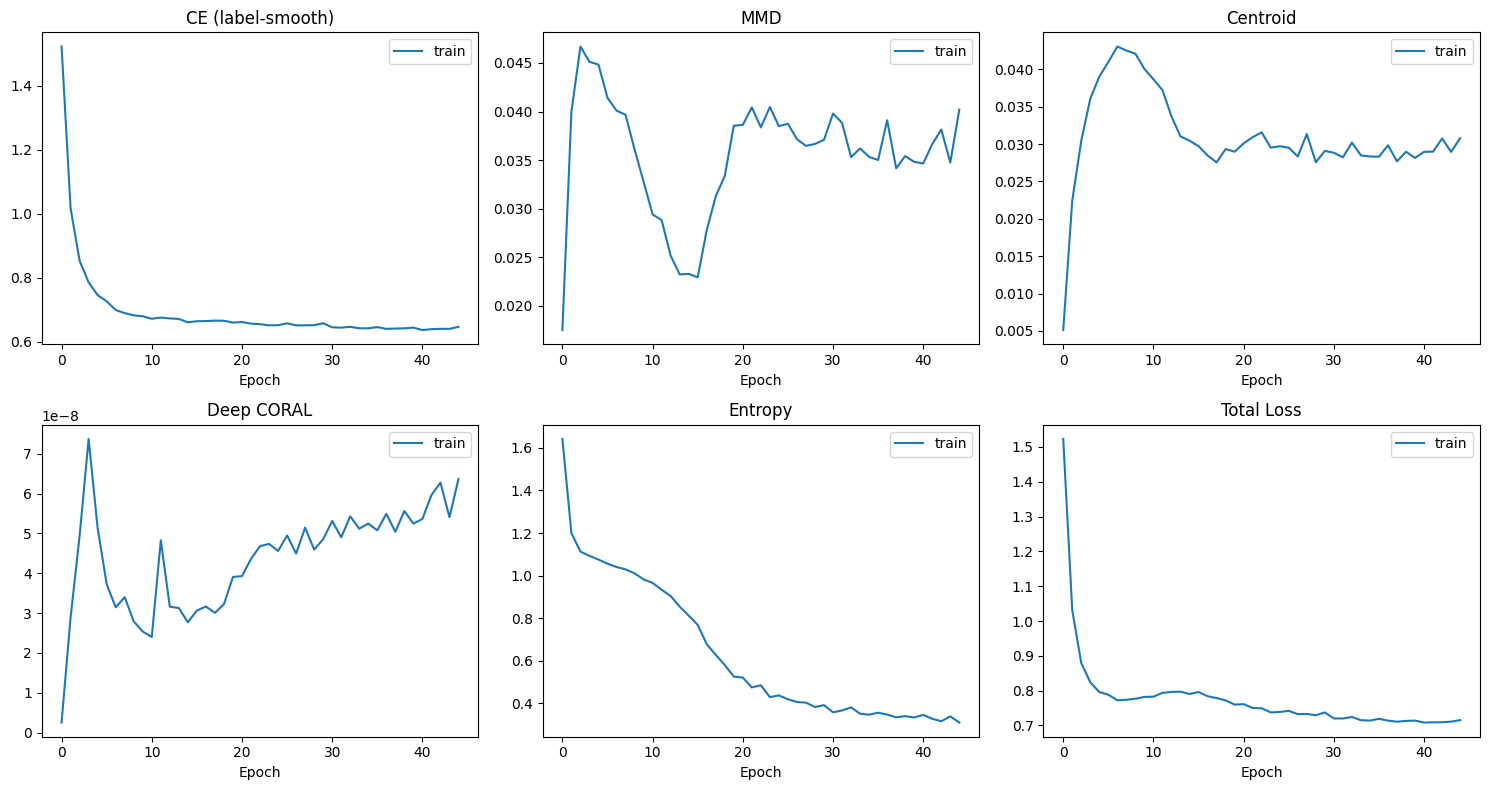

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

loss_keys = ["ce_loss", "mmd_loss", "cen_loss", "coral_loss", "ent_loss", "loss"]
titles    = ["CE (label-smooth)", "MMD", "Centroid",
             "Deep CORAL", "Entropy", "Total Loss"]

for ax, key, title in zip(axes.flat, loss_keys, titles):
    if key in history.history:
        ax.plot(history.history[key], label="train")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("v6_loss_curves.png", dpi=120)
plt.show()

## 11 · Gene attention weights

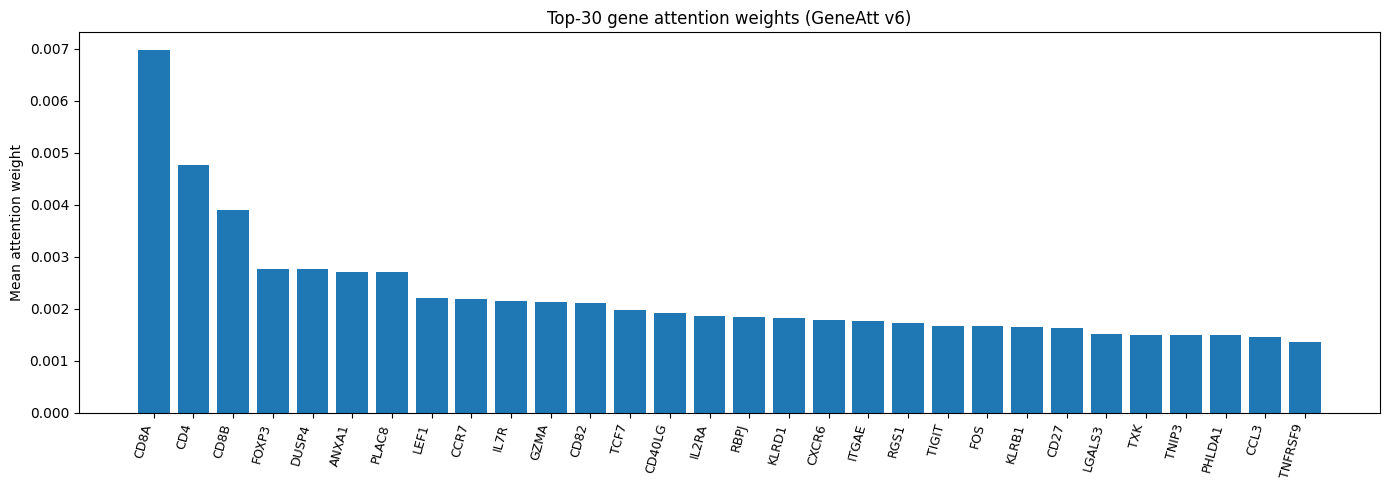

Top-10 genes: [np.str_('CD8A'), np.str_('CD4'), np.str_('CD8B'), np.str_('FOXP3'), np.str_('DUSP4'), np.str_('ANXA1'), np.str_('PLAC8'), np.str_('LEF1'), np.str_('CCR7'), np.str_('IL7R')]


In [72]:
gene_names = np.load(os.path.join(ROOT, "step3_gene_names.npy"), allow_pickle=True)

# Average attention over first 2000 source cells
sample = X_train[:2000]
att_logits = model.att_out(
    model.att_d2(
        model.att_h2(
            model.att_d1(
                model.att_h1(sample, training=False),
            training=False)),
    training=False))
gene_weights = tf.nn.softmax(att_logits, axis=-1).numpy().mean(axis=0)

top_k = 30
top_idx = np.argsort(gene_weights)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(top_k), gene_weights[top_idx])
ax.set_xticks(range(top_k))
ax.set_xticklabels(gene_names[top_idx], rotation=75, ha="right", fontsize=9)
ax.set_title("Top-30 gene attention weights (GeneAtt v6)")
ax.set_ylabel("Mean attention weight")
plt.tight_layout()
plt.savefig("v6_gene_attention.png", dpi=120)
plt.show()

print("Top-10 genes:", list(gene_names[top_idx[:10]]))

## 12 · Latent space UMAP

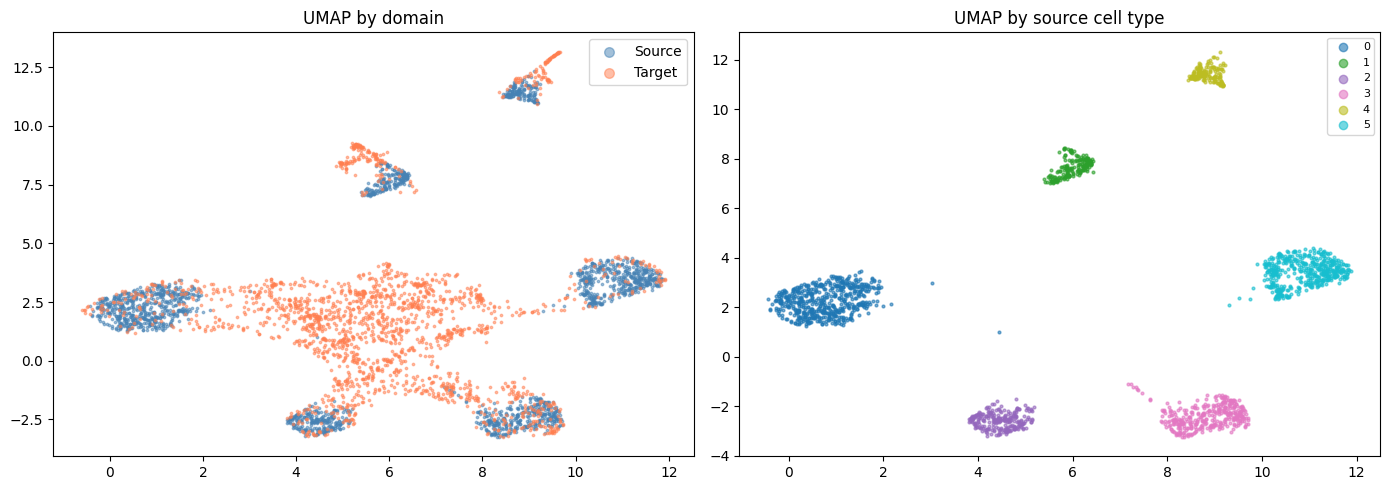

In [73]:
try:
    import umap

    N_SRC = 2000
    N_TGT = 2000

    idx_src = np.random.choice(len(X_train), N_SRC, replace=False)
    idx_tgt = np.random.choice(len(X_tgt),   N_TGT, replace=False)

    z_src_sub, _ = model.encode(X_train[idx_src], training=False)
    z_tgt_sub, _ = model.encode(X_tgt[idx_tgt],   training=False)

    z_all = np.vstack([z_src_sub.numpy(), z_tgt_sub.numpy()])
    domain_label = ["Source"] * N_SRC + ["Target"] * N_TGT

    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30)
    emb = reducer.fit_transform(z_all)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = {"Source": "steelblue", "Target": "coral"}
    for dom in ["Source", "Target"]:
        mask = np.array(domain_label) == dom
        axes[0].scatter(emb[mask, 0], emb[mask, 1],
                        c=colors[dom], s=3, alpha=0.5, label=dom)
    axes[0].set_title("UMAP by domain")
    axes[0].legend(markerscale=4)

    class_colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for c, cls in enumerate(le.classes_):
        mask = y_train_enc[idx_src] == c
        axes[1].scatter(emb[:N_SRC][mask, 0], emb[:N_SRC][mask, 1],
                        c=[class_colors[c]], s=4, alpha=0.6, label=cls)
    axes[1].set_title("UMAP by source cell type")
    axes[1].legend(markerscale=3, fontsize=8)

    plt.tight_layout()
    plt.savefig("v6_umap.png", dpi=120)
    plt.show()

except ImportError:
    print("umap-learn not installed. Skipping UMAP. Install with: pip install umap-learn")

## 13 · Domain gap diagnostics

In [74]:
# Compute CORAL distance between source and target latent distributions
N = 2000
idx_s = np.random.choice(len(X_train), N, replace=False)
idx_t = np.random.choice(len(X_tgt),   N, replace=False)

zs, _ = model.encode(X_train[idx_s], training=False)
zt, _ = model.encode(X_tgt[idx_t],   training=False)

zs, zt = zs.numpy(), zt.numpy()

def coral_distance(A, B):
    Cs = np.cov(A.T)
    Ct = np.cov(B.T)
    diff = Cs - Ct
    return float(np.sqrt(np.sum(diff ** 2))) / (4 * A.shape[1] ** 2)

coral_d = coral_distance(zs, zt)
mean_diff = np.linalg.norm(zs.mean(axis=0) - zt.mean(axis=0))

print(f"Latent CORAL distance  : {coral_d:.6f}")
print(f"Latent mean difference : {mean_diff:.4f}")
print(f"Source latent std (avg): {zs.std(axis=0).mean():.4f}")
print(f"Target latent std (avg): {zt.std(axis=0).mean():.4f}")

Latent CORAL distance  : 0.000107
Latent mean difference : 0.7097
Source latent std (avg): 0.4821
Target latent std (avg): 0.4537


## 14 · Full model comparison table

In [75]:
results = pd.DataFrame([
    {"Model": "DANN v2",           "Source F1": 0.870, "Target F1": 0.385, "Key change": "Gradient reversal + MMD"},
    {"Model": "CDAN-E",            "Source F1": 0.882, "Target F1": 0.391, "Key change": "Conditional DANN + entropy"},
    {"Model": "Joint VAE",         "Source F1": 0.871, "Target F1": 0.395, "Key change": "VAE + MMD in latent space"},
    {"Model": "GeneAtt v3",        "Source F1": 0.896, "Target F1": 0.407, "Key change": "Gene attention + MMD + centroid"},
    {"Model": "GeneAtt v4",        "Source F1": 0.903, "Target F1": 0.420, "Key change": "2-layer att + mixup + entropy"},
    {"Model": "GeneAtt v5",        "Source F1": 0.902, "Target F1": 0.438, "Key change": "Fix: independent target std + dead gene removal"},
    {"Model": "GeneAtt v6 (this)", "Source F1": round(src_f1, 4), "Target F1": round(tgt_f1, 4),
     "Key change": "Deep CORAL (latent) + label smoothing ε=0.1"},
])

best_tgt = results["Target F1"].max()
print(f"\n{'Model':20s} {'Source F1':>10s} {'Target F1':>10s}  Key change")
print("-" * 90)
for _, row in results.iterrows():
    mark = " ◄ best" if row["Target F1"] == best_tgt else ""
    print(f"{row['Model']:20s} {row['Source F1']:>10.4f} {row['Target F1']:>10.4f}  {row['Key change']}{mark}")


Model                 Source F1  Target F1  Key change
------------------------------------------------------------------------------------------
DANN v2                  0.8700     0.3850  Gradient reversal + MMD
CDAN-E                   0.8820     0.3910  Conditional DANN + entropy
Joint VAE                0.8710     0.3950  VAE + MMD in latent space
GeneAtt v3               0.8960     0.4070  Gene attention + MMD + centroid
GeneAtt v4               0.9030     0.4200  2-layer att + mixup + entropy
GeneAtt v5               0.9020     0.4380  Fix: independent target std + dead gene removal ◄ best
GeneAtt v6 (this)        0.8902     0.3922  Deep CORAL (latent) + label smoothing ε=0.1


## 15 · Save model weights

In [76]:
weights_path = os.path.join(ROOT, "saved_models", "gene_attention_v6.weights.h5")
os.makedirs(os.path.dirname(weights_path), exist_ok=True)
model.save_weights(weights_path)
print(f"Weights saved to: {weights_path}")

Weights saved to: /Users/kirtan/Projects /NNDL/saved_models/gene_attention_v6.weights.h5
